## Simulating traffic around a lock (varying water levels)
In this notebook, we simulate a lock on a network which two opposingly directed vessels have to pass. We add a pre-coded complex lock object on the graph: only one vessel can be levelled at a time. The second vessel waits until the first vessel has passed the lock. 

#### 0. Import libraries

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from shapely.geometry import Point, LineString
from shapely.ops import transform

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.plotutils import generate_vessel_gantt_chart

# import of modules important for locking
from opentnsim.lock import lock_new as lock_module
from opentnsim import vessel_traffic_service as vessel_traffic_service_module

# packege(s) needed to create hydrodynamic data
import xarray as xr
import numpy as np

# package(s) needed for inspecting the output
import pandas as pd
import matplotlib.pyplot as plt

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.7


#### 1. Define object classes

In [2]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (
        lock_module.PassesLockComplex,             # allows to interact with a lock
        opentnsim.core.Identifiable,               # allows to give the object a name and a random ID,
        opentnsim.core.Movable,                    # allows the object to move, with a fixed speed, while logging this activity
        opentnsim.core.VesselProperties,           # allows vessel to have dimensions, namely a length (L), width (B), and draught (T)
        opentnsim.core.ExtraMetadata,              # allow additional information, such as an arrival time (required for passing a lock)
        opentnsim.graph.HasMultiDiGraph,           # allow to operate on a graph that can include parallel edges from and to the same nodes
        opentnsim.output.HasOutput,                # allow additional output to be stored
    ), 
    {}
)

#### 2. Create graph

In [3]:
# define reference systems
wgs84eqd = pyproj.CRS('4087')
wgs84rad = pyproj.CRS('4326')

# define transformer functions
wgs84eqd_to_wgs84rad = pyproj.transformer.Transformer.from_crs(wgs84eqd,wgs84rad,always_xy=True).transform #equidistant wgs84 to radial wgs84
wgs84rad_to_wgs84eqd = pyproj.transformer.Transformer.from_crs(wgs84rad,wgs84eqd,always_xy=True).transform #radial wgs84 to equidistant wgs84

# create a directed graph
graph = nx.MultiDiGraph()

# add nodes
graph.add_node('0',geometry=transform(wgs84eqd_to_wgs84rad,Point(-5000,0)))
graph.add_node('1',geometry=transform(wgs84eqd_to_wgs84rad,Point(5000,0)))

# add edges
graph.add_edge('0','1',geometry=transform(wgs84eqd_to_wgs84rad,LineString([Point(-5000,0),Point(5000,0)])),length_m=10000, weight=1)
graph.add_edge('1','0',geometry=transform(wgs84eqd_to_wgs84rad,LineString([Point(5000,0),Point(-5000,0)])),length_m=10000, weight=1);


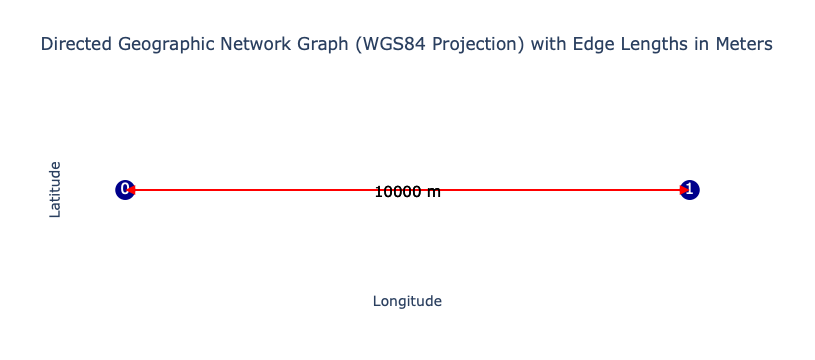

In [4]:
opentnsim.graph.plot_graph(graph)

In [5]:
nodes = graph.nodes
nodes

NodeView(('0', '1'))

#### 3. Run simulation

In [6]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [7]:
# start simpy environment
simulation_start = datetime.datetime(2025, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

In [8]:
hydrodynamic_data = xr.Dataset()

time = pd.date_range(start = simulation_start,
                     end = simulation_start+pd.Timedelta(days=7),
                     freq = pd.Timedelta(minutes=5))

static_water_level = np.zeros(len(time))
tidal_amplitude = 1.0
tidal_period = 12.5 #hours
tidal_water_level = [tidal_amplitude*np.sin(2*np.pi*(t-simulation_start).total_seconds()/(tidal_period*3600)) for t in time]

water_level_data = xr.DataArray(data=[static_water_level,tidal_water_level],coords={'STATION':graph.nodes,'TIME':time})

hydrodynamic_data['Water level'] = water_level_data

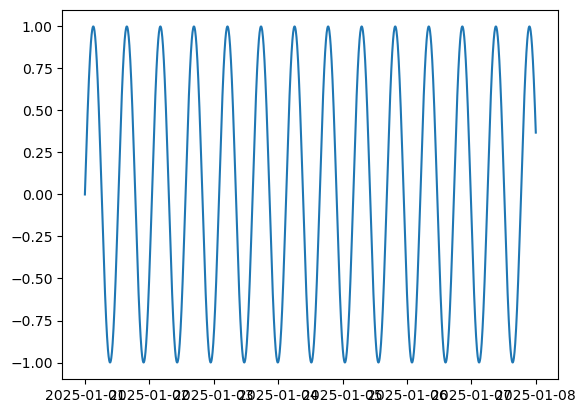

In [9]:
plt.plot(time,hydrodynamic_data.sel({'STATION':'1'})['Water level'].values)

In [10]:
# add graph to environment
env.graph = graph

# add components important for locking to the environment
env.vessel_traffic_service = vessel_traffic_service_module.VesselTrafficService(graph = graph,
                                                                                hydrodynamic_information = hydrodynamic_data)

lock = lock_module.IsLockComplex(
    env=env,
    name='Lock',
    node_open='0',
    node_A = '0',
    node_B = '1',
    distance_lock_doors_A_to_waiting_area_A = 4800,
    distance_lock_doors_B_to_waiting_area_B = 4800,
    distance_from_start_node_to_lock_doors_A = 4800,
    distance_from_end_node_to_lock_doors_B = 4800,
    lock_length = 400,
    lock_width = 50,
    lock_depth = 15,
    sailing_distance_to_crossing_point = 1800,
    doors_opening_time= 300,
    doors_closing_time= 300,
    speed_reduction_factor_lock_chamber=0.5,
    sailing_in_time_gap_through_doors = 300,
    sailing_in_speed_sea = 1.5,
    sailing_in_speed_canal = 1.5,
    sailing_out_time_gap_through_doors = 120,
    sailing_time_before_opening_lock_doors = 600,
    sailing_time_before_closing_lock_doors = 120,
    detector_nodes = ['0','1'],
    predictive=False
)

# create vessels from dict 
data_vessel_1 = {
    "env": env,                                          # needed for simpy simulation
    "name": "Vessel 1",                                  # required by Identifiable
    "geometry": env.graph.nodes['0']['geometry'],        # required by Locatable
    "route": nx.dijkstra_path(env.graph, "0", "1"),      # required by Routeable
    "v": 4,                                              # required by Movable, 4 m/s to check if the distance is covered in the expected time
    "L": 100,                                            # required by VesselProperties, interacts with the lock capacity
    "B": 20,                                             # required by VesselProperties
    "T": 10,                                             # required by VesselProperties
    "type": 'tanker',                                    # required by VesselProperties
    "arrival_time": pd.Timestamp('2025-01-01 00:00:00')  # required by PassesLockComplex
}  
vessel_1 = Vessel(**data_vessel_1)
vessel_1.name = 'Vessel 1'

data_vessel_2 = {
    "env": env,                                          # needed for simpy simulation
    "name": "Vessel 2",                                  # required by Identifiable
    "geometry": env.graph.nodes['1']['geometry'],        # required by Locatable
    "route": nx.dijkstra_path(env.graph, "1", "0"),      # required by Routeable
    "v": 4,                                              # required by Movable, 4 m/s to check if the distance is covered in the expected time
    "L": 100,                                            # required by VesselProperties, interacts with the lock capacity
    "B": 20,                                             # required by VesselProperties
    "T": 10,                                             # required by VesselProperties
    "type": 'tanker',                                    # required by VesselProperties
    "arrival_time": pd.Timestamp('2025-01-01 00:05:00')  # required by PassesLockComplex
}  
vessel_2 = Vessel(**data_vessel_2)
vessel_2.name = 'Vessel 2'

# start the simulation
env.process(mission(env, vessel_1))
env.process(mission(env, vessel_2))
env.run()

In [11]:
lock.vessel_planning

,id,bound,L,B,T,operation_index,time_of_registration,time_of_acceptance,time_arrival_at_waiting_area,time_arrival_at_lineup_area,time_lock_passing_start,time_lock_entry_start,time_lock_entry_stop,time_lock_departure_start,time_lock_departure_stop,time_lock_passing_stop,delay,time_potential_lock_door_opening_stop,time_potential_lock_door_closure_start
0,2a133da2-d24b-487c-a483-aa866ffe9900,0,100,20,10,0,2025-01-01 00:00:00,2025-01-01 00:00:00,2025-01-01 00:00:00,NaN,2025-01-01 00:12:30,2025-01-01 00:20:00,2025-01-01 00:23:53.333333333,2025-01-01 00:43:03.333333333,2025-01-01 00:43:51.929445685,2025-01-01 00:51:21.929445685,0 days 00:00:00,2025-01-01 00:10:00.000000000,2025-01-01 00:23:53.333333333
1,fd356668-9190-4186-8cbb-b039f4cc2a37,1,100,20,10,1,2025-01-01 00:00:00,2025-01-01 00:00:00,2025-01-01 00:00:00,NaN,2025-01-01 00:51:21.929445685,2025-01-01 00:58:51.929445685,2025-01-01 01:02:45.262779018,2025-01-01 01:12:55.262779018,2025-01-01 01:13:43.858891370,2025-01-01 01:21:13.858891370,0 days 00:38:51.929445685,2025-01-01 00:48:51.929445685,2025-01-01 01:02:45.262779018


In [12]:
lock.opening_area

12.0

In [13]:
lock.operation_planning

,bound,vessels,capacity_L,capacity_B,time_potential_lock_door_opening_stop,time_operation_start,time_entry_start,time_entry_stop,time_door_closing_start,time_door_closing_stop,...,time_door_opening_stop,time_departure_start,time_departure_stop,time_operation_stop,time_potential_lock_door_closure_start,wlev_A,wlev_B,maximum_individual_delay,total_delay,status
lock_operation,,,,,,,,,,,,,,,,,,,,,
0,0,[<__main__.Vessel object at 0x16c71af90>],300,30,2025-01-01 00:10:00,2025-01-01 00:12:30,2025-01-01 00:20:00,2025-01-01 00:23:53.333333333,2025-01-01 00:23:53.333333333,2025-01-01 00:28:53.333333333,...,2025-01-01 00:43:03.333333333,2025-01-01 00:43:03.333333333,2025-01-01 00:43:51.929445685,2025-01-01 00:51:21.929445685,2025-01-01 00:45:51.929445685,NaN,NaN,0 days 00:00:00,0 days 00:00:00,ready
1,1,[<__main__.Vessel object at 0x16546f550>],300,30,2025-01-01 00:48:51.929445685,2025-01-01 00:51:21.929445685,2025-01-01 00:58:51.929445685,2025-01-01 01:02:45.262779018,2025-01-01 01:02:45.262779018,2025-01-01 01:07:45.262779018,...,2025-01-01 01:12:55.262779018,2025-01-01 01:12:55.262779018,2025-01-01 01:13:43.858891370,2025-01-01 01:21:13.858891370,2025-01-01 01:15:43.858891370,NaN,NaN,0 days 00:38:51.929445685,0 days 00:38:51.929445685,ready


#### 4. Inspect output

In [14]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_1.logbook)

print("'{}' logbook data:".format(vessel_1.name))  
print('')

display(df)

'Vessel 1' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 0 to node 1 start,2025-01-01 00:00:00.000000,0,POINT (-0.0449157642059761 0)
1,Sailing to first lock doors start,2025-01-01 00:00:00.000000,"{'origin': '', 'destination': '', 'route': [],...",POINT (-0.0449157642059761 0)
2,Sailing to first lock doors stop,2025-01-01 00:20:00.000000,"{'origin': '', 'destination': '', 'route': [],...",POINT (-0.001796630568239 0)
3,Sailing to position in lock start,2025-01-01 00:20:00.000000,"{'origin': '', 'destination': '', 'route': [],...",POINT (-0.001796630568239 0)
4,Sailing to position in lock stop,2025-01-01 00:23:53.333333,"{'origin': '', 'destination': '', 'route': [],...",POINT (0.0013474729261793 0)
5,Levelling start,2025-01-01 00:28:53.333333,"{'origin': '', 'destination': '', 'route': [],...",POINT (0.0013474729261793 0)
6,Levelling stop,2025-01-01 00:38:03.333333,"{'origin': '', 'destination': '', 'route': [],...",POINT (0.0013474729261793 0)
7,Sailing to second lock doors start,2025-01-01 00:43:03.333333,"{'origin': '', 'destination': '', 'route': [],...",POINT (0.0013474729261793 0)
8,Sailing to second lock doors stop,2025-01-01 00:43:51.929446,"{'origin': '', 'destination': '', 'route': [],...",POINT (0.001796630568239 0)
9,Sailing to lock complex exit start,2025-01-01 00:43:51.929446,"{'origin': '', 'destination': '', 'route': [],...",POINT (0.001796630568239 0)


In [15]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel_2.logbook)

print("'{}' logbook data:".format(vessel_2.name))  
print('')

display(df)

'Vessel 2' logbook data:



,Message,Timestamp,Value,Geometry
0,Sailing from node 1 to node 0 start,2025-01-01 00:00:00.000000,0,POINT (0.0449157642059761 0)
1,Waiting start,2025-01-01 00:00:00.000000,"{'origin': '', 'destination': '', 'route': [],...",POINT (0.0449157642059761 0)
2,Waiting stop,2025-01-01 00:38:51.929445,"{'origin': '', 'destination': '', 'route': [],...",POINT (0.0449157642059761 0)
3,Sailing to first lock doors start,2025-01-01 00:38:51.929445,"{'origin': '', 'destination': '', 'route': [],...",POINT (0.0449157642059761 0)
4,Sailing to first lock doors stop,2025-01-01 00:58:51.929445,"{'origin': '', 'destination': '', 'route': [],...",POINT (0.001796630568239 0)
5,Sailing to position in lock start,2025-01-01 00:58:51.929445,"{'origin': '', 'destination': '', 'route': [],...",POINT (0.001796630568239 0)
6,Sailing to position in lock stop,2025-01-01 01:02:45.262778,"{'origin': '', 'destination': '', 'route': [],...",POINT (-0.0013474729261793 0)
7,Levelling start,2025-01-01 01:07:45.262778,"{'origin': '', 'destination': '', 'route': [],...",POINT (-0.0013474729261793 0)
8,Levelling stop,2025-01-01 01:24:35.262778,"{'origin': '', 'destination': '', 'route': [],...",POINT (-0.0013474729261793 0)
9,Sailing to second lock doors start,2025-01-01 01:29:35.262778,"{'origin': '', 'destination': '', 'route': [],...",POINT (-0.0013474729261793 0)


In [16]:
# load the logbook data into a dataframe
lock_df = pd.DataFrame.from_dict(lock.logbook)

print("'{}' logbook data:".format(lock.name))  
print('')

display(lock_df)

'Lock' logbook data:



,Message,Timestamp,Value,Geometry
0,Lock doors closing start,2025-01-01 00:23:53.333333,{},0
1,Lock doors closing stop,2025-01-01 00:28:53.333333,{},0
2,Lock chamber converting start,2025-01-01 00:28:53.333333,{},0
3,Lock chamber converting stop,2025-01-01 00:38:03.333333,{},1
4,Lock doors opening start,2025-01-01 00:38:03.333333,{},1
5,Lock doors opening stop,2025-01-01 00:43:03.333333,{},1
6,Lock doors closing start,2025-01-01 01:02:45.262778,{},1
7,Lock doors closing stop,2025-01-01 01:07:45.262778,{},1
8,Lock chamber converting start,2025-01-01 01:07:45.262778,{},1
9,Lock chamber converting stop,2025-01-01 01:24:35.262778,{},0


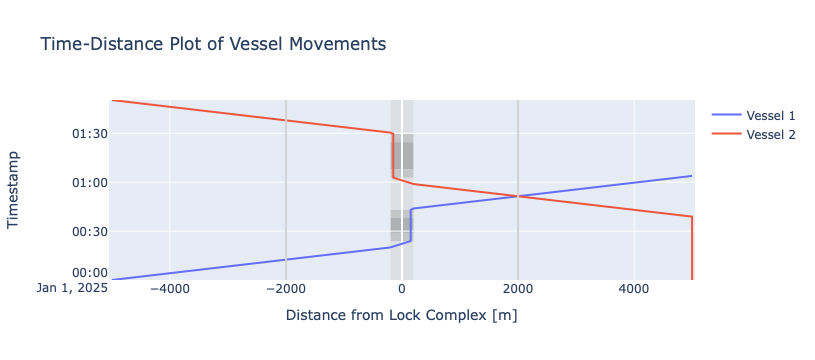

In [17]:
# We can plot the time-distance diagram
lock.create_time_distance_plot_plotly(
    vessels = [vessel_1,vessel_2], 
    xlimmin = -5050, 
    xlimmax = 5050
)

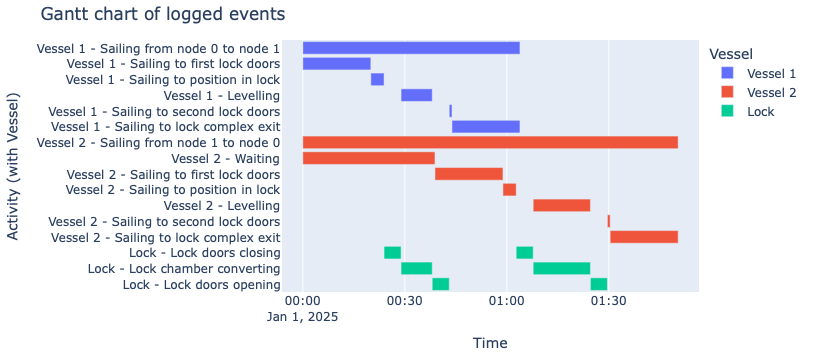

In [18]:
df_eventtable = opentnsim.core.logutils.logbook2eventtable([vessel_1, vessel_2, lock])
generate_vessel_gantt_chart(df_eventtable)

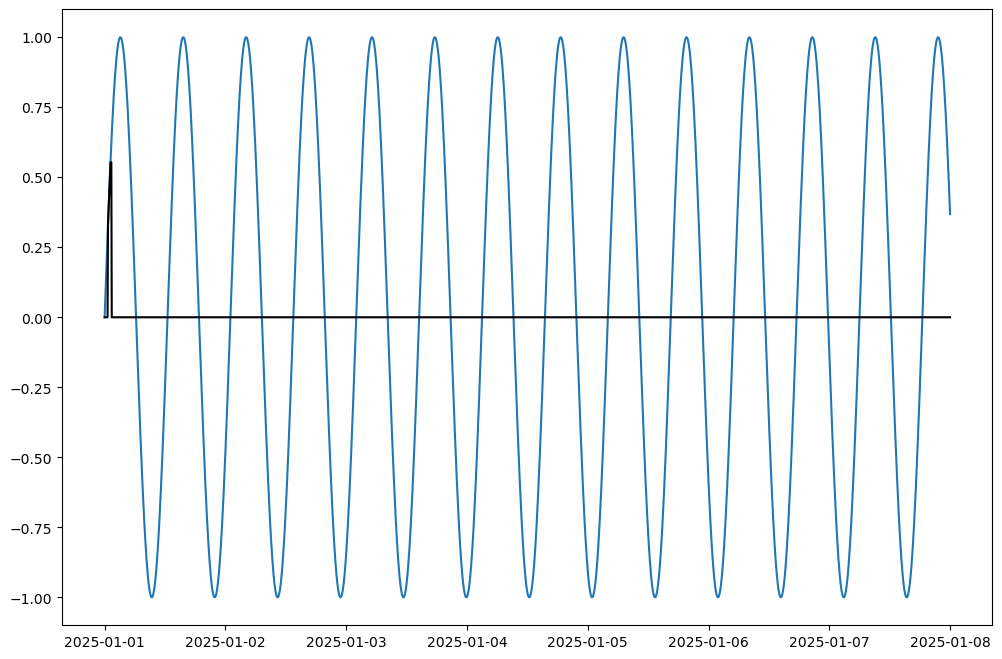

In [19]:
fig,ax = plt.subplots(figsize=[12,8])
ax.plot(hydrodynamic_data["TIME"],hydrodynamic_data.sel({'STATION':'1'})["Water level"])
ax.plot(hydrodynamic_data["TIME"],lock.water_level,color='k')

In [20]:
levelling_times = []
water_level_difference = []
stationA_index = np.where(np.array(list((hydrodynamic_data['STATION'].values))) == lock.start_node)[0][0]
stationB_index = np.where(np.array(list((hydrodynamic_data['STATION'].values))) == lock.end_node)[0][0]
H_A = hydrodynamic_data["Water level"][stationA_index].values.copy()
H_B = hydrodynamic_data["Water level"][stationB_index].values.copy()
for time in pd.date_range(pd.Timestamp('2025-01-01T00:00:00.000000000'),pd.Timestamp('2025-01-01T12:30:00.000000000'),freq=pd.Timedelta(minutes=5)):
    time_index = np.absolute(hydrodynamic_data['TIME'][:].values - np.datetime64(time)).argmin()
    wlev_A = H_A[time_index]
    wlev_B = H_B[time_index]
    wlev_dif = wlev_A - wlev_B
    water_level_difference.append(wlev_dif)
    levelling_times.append(lock.determine_levelling_time(time,direction=1,wlev_init=wlev_dif,prediction=True)[0])

Text(0, 0.5, 'Levelling time [min]')

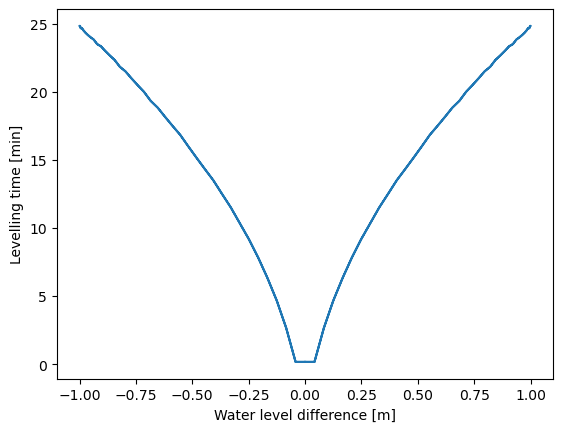

In [21]:
plt.plot(water_level_difference,np.array(levelling_times)/60)
plt.xlabel('Water level difference [m]')
plt.ylabel('Levelling time [min]')

In [22]:
def get_vessels_during_leveling(lock, vessels: list) -> list:
    """
    Identifies which vessels were present during each lock leveling event.

    Parameters:
    - lock: An object with a `.logbook` attribute (list of dicts with 'Message' and 'Timestamp').
    - vessels: List of vessel objects, each with a `.logbook` attribute and optional `.name`.

    Returns:
    - List of dicts with keys: 'leveling_start', 'leveling_stop', 'vessels_present'
    """
    # Convert lock logbook to DataFrame
    lock_df = pd.DataFrame(lock.logbook)

    # Extract leveling start/stop events
    leveling_starts = lock_df[lock_df["Message"] == "Lock chamber converting start"]
    leveling_stops = lock_df[lock_df["Message"] == "Lock chamber converting stop"]

    # Ensure matching pairs
    leveling_events = pd.DataFrame({
        "leveling_start": leveling_starts["Timestamp"].values,
        "leveling_stop": leveling_stops["Timestamp"].values
    })

    leveling_cycles = []
    for _, level_event in leveling_events.iterrows():
        vessels_present = []
        for vessel in vessels:
            vessel_df = pd.DataFrame(vessel.logbook)
            vessel_df["Timestamp"] = pd.to_datetime(vessel_df["Timestamp"])
            name = getattr(vessel, "name", f"Vessel_{vessels.index(vessel)+1}")

            # Find levelling start/stop pairs
            levelling_starts = vessel_df[vessel_df["Message"] == "Levelling start"]
            levelling_stops = vessel_df[vessel_df["Message"] == "Levelling stop"]

            for i in range(min(len(levelling_starts), len(levelling_stops))):
                start = levelling_starts.iloc[i]["Timestamp"]
                stop = levelling_stops.iloc[i]["Timestamp"]
                if start <= level_event["leveling_stop"] and stop >= level_event["leveling_start"]:
                    vessels_present.append(name)
                    break

        leveling_cycles.append({
            "leveling_start": level_event["leveling_start"],
            "leveling_stop": level_event["leveling_stop"],
            "vessels_present": vessels_present
        })

    return leveling_cycles

In [23]:
def calculate_cycle_looptimes(leveling_cycles: list, vessels: list) -> pd.DataFrame:
    """
    Calculates the looptime for each locking cycle.

    Looptime is defined as the time between:
    - the last vessel exiting the lock in the previous cycle ('Sailing to lock complex exit start')
    - the first vessel entering the lock in the current cycle ('Sailing to first lock doors stop')

    Parameters:
    - leveling_cycles: List of dicts from get_vessels_during_leveling, each with 'vessels_present'.
    - vessels: List of vessel objects, each with a `.logbook` attribute and optional `.name`.

    Returns:
    - DataFrame with columns: 'cycle', 'looptime_seconds'
    """
    # Create a lookup for vessel logbooks
    vessel_logs = {}
    for vessel in vessels:
        name = getattr(vessel, "name", f"Vessel_{vessels.index(vessel)+1}")
        vessel_logs[name] = vessel.logbook

    results = []
    for i, cycle in enumerate(leveling_cycles):
        if i == 0:
            results.append({
                "cycle": i + 1,
                "looptime_seconds": 0
            })
            continue

        prev_vessels = leveling_cycles[i - 1]["vessels_present"]
        curr_vessels = cycle["vessels_present"]

        # Get latest exit time from previous cycle
        prev_exit_times = [
            event["Timestamp"]
            for v in prev_vessels
            for event in vessel_logs.get(v, [])
            if event["Message"] == "Sailing to lock complex exit start"
        ]
        last_exit = max(prev_exit_times) if prev_exit_times else None

        # Get earliest entry time from current cycle
        curr_entry_times = [
            event["Timestamp"]
            for v in curr_vessels
            for event in vessel_logs.get(v, [])
            if event["Message"] == "Sailing to first lock doors stop"
        ]
        first_entry = min(curr_entry_times) if curr_entry_times else None

        # Calculate looptime
        looptime = (first_entry - last_exit).total_seconds() if last_exit and first_entry else None

        results.append({
            "cycle": i + 1,
            "looptime_seconds": looptime
        })

    return pd.DataFrame(results)

In [24]:
def calculate_detailed_cycle_time(lock, vessels, leveling_cycles):
    """
    Calculates detailed timing metrics for full lock cycles (up + down) using logbook data.

    Each full cycle consists of two consecutive leveling events: one upward and one downward.
    The function computes:
    - Looptimes before each phase (t_l_up, t_l_down)
    - Entry and exit durations for vessels based on first and last movement timestamps
    - Lock operation durations (door opening/closing, water level adjustment) per cycle
    - Total cycle time (Tc)
    - Locking system intensity (I_s = 2 * n_max / (Tc / 3600))

    Parameters
    ----------
    lock : object
        Lock object with a `.logbook` attribute containing a list of dicts with 'Message' and 'Timestamp'.
    vessels : list
        List of vessel objects, each with a `.logbook` attribute and optional `.name`.
    leveling_cycles : list
        Output from `get_vessels_during_leveling`, containing dicts with 'leveling_start', 'leveling_stop', and 'vessels_present'.

    Returns
    -------
    pd.DataFrame
        A DataFrame with one row per full lock cycle and the following columns:
        - t_l_up: Looptime before upcycle
        - sum_t_i_up: Time between first vessel's entry start and last vessel's entry stop (upcycle)
        - T_close_up, T_waterlevel_up, T_open_up: Lock operation durations (upcycle)
        - sum_t_u_up: Time between first vessel's exit start and last vessel's exit stop (upcycle)
        
        - t_l_down: Looptime before downcycle
        - sum_t_i_down: Time between first vessel's entry start and last vessel's entry stop (downcycle)
        - T_close_down, T_waterlevel_down, T_open_down: Lock operation durations (downcycle)
        - sum_t_u_down: Time between first vessel's exit start and last vessel's exit stop (downcycle)
        
        - Tc_seconds: Total time for the full cycle (up + down)
        - up_vessels: List of vessels in upcycle
        - down_vessels: List of vessels in downcycle
        - I_s: Locking system intensity (vessels per hour)

    Notes
    -----
    - Lock operation durations are extracted per cycle from the lock's logbook using start/stop message pairs.
    - Vessel entry and exit durations are calculated using the earliest and latest timestamps of relevant movement messages.
    - The function assumes `leveling_cycles` are chronologically ordered and alternate between up and down phases.
    """

    def get_duration(df, start_msg, stop_msg):
        starts = df[df["Message"] == start_msg]["Timestamp"].reset_index(drop=True)
        stops = df[df["Message"] == stop_msg]["Timestamp"].reset_index(drop=True)
        return [(stop - start).total_seconds() for start, stop in zip(starts, stops)]

    def get_time_range(log, start_msg, stop_msg):
        df = pd.DataFrame(log)
        df["Timestamp"] = pd.to_datetime(df["Timestamp"])
        starts = df[df["Message"] == start_msg]["Timestamp"]
        stops = df[df["Message"] == stop_msg]["Timestamp"]
        if not starts.empty and not stops.empty:
            return starts.iloc[0], stops.iloc[-1]
        return None, None

    lock_df = pd.DataFrame(lock.logbook)
    lock_df["Timestamp"] = pd.to_datetime(lock_df["Timestamp"])

    # Extract per-cycle lock durations
    T_close_list = get_duration(lock_df, "Lock doors closing start", "Lock doors closing stop")
    T_waterlevel_list = get_duration(lock_df, "Lock chamber converting start", "Lock chamber converting stop")
    T_open_list = get_duration(lock_df, "Lock doors opening start", "Lock doors opening stop")

    vessel_logs = {
        getattr(v, "name", f"Vessel_{i+1}"): v.logbook
        for i, v in enumerate(vessels)
    }

    results = []
    for i in range(0, len(leveling_cycles) - 1, 2):
        up_cycle = leveling_cycles[i]
        down_cycle = leveling_cycles[i + 1]

        up_vessels = up_cycle["vessels_present"]
        down_vessels = down_cycle["vessels_present"]

        # t_l_up
        if i == 0:
            t_l_up = 0
        else:
            prev_down_vessels = leveling_cycles[i - 1]["vessels_present"]
            last_exit_prev = max([
                get_time_range(vessel_logs[v], "Sailing to second lock doors start", "Sailing to second lock doors stop")[1]
                for v in prev_down_vessels if v in vessel_logs
            ], default=None)
            first_entry_up = min([
                get_time_range(vessel_logs[v], "Sailing to first lock doors stop", "Sailing to first lock doors stop")[0]
                for v in up_vessels if v in vessel_logs
            ], default=None)
            t_l_up = (first_entry_up - last_exit_prev).total_seconds() if first_entry_up and last_exit_prev else 0

        # t_l_down
        last_exit_up = max([
            get_time_range(vessel_logs[v], "Sailing to second lock doors start", "Sailing to second lock doors stop")[1]
            for v in up_vessels if v in vessel_logs
        ], default=None)
        first_entry_down = min([
            get_time_range(vessel_logs[v], "Sailing to first lock doors stop", "Sailing to first lock doors stop")[0]
            for v in down_vessels if v in vessel_logs
        ], default=None)
        t_l_down = (first_entry_down - last_exit_up).total_seconds() if first_entry_down and last_exit_up else 0

        # Entry and exit durations using time range
        entry_start_up, entry_stop_up = None, None
        exit_start_up, exit_stop_up = None, None
        entry_start_down, entry_stop_down = None, None
        exit_start_down, exit_stop_down = None, None

        entry_times_up = [get_time_range(vessel_logs[v], "Sailing to position in lock start", "Sailing to position in lock stop") for v in up_vessels if v in vessel_logs]
        exit_times_up = [get_time_range(vessel_logs[v], "Sailing to second lock doors start", "Sailing to second lock doors stop") for v in up_vessels if v in vessel_logs]
        entry_times_down = [get_time_range(vessel_logs[v], "Sailing to position in lock start", "Sailing to position in lock stop") for v in down_vessels if v in vessel_logs]
        exit_times_down = [get_time_range(vessel_logs[v], "Sailing to second lock doors start", "Sailing to second lock doors stop") for v in down_vessels if v in vessel_logs]

        # Sum of entering times (up), - Part III, Ch 3, Eq. 3.2
        entry_start_up = min([t[0] for t in entry_times_up if t[0] is not None], default=None)
        entry_stop_up = max([t[1] for t in entry_times_up if t[1] is not None], default=None)
        sum_t_i_up = (entry_stop_up - entry_start_up).total_seconds() if entry_start_up and entry_stop_up else 0
        
        # Sum of exiting times (up), - Part III, Ch 3, Eq. 3.4
        exit_start_up = min([t[0] for t in exit_times_up if t[0] is not None], default=None)
        exit_stop_up = max([t[1] for t in exit_times_up if t[1] is not None], default=None)
        sum_t_u_up = (exit_stop_up - exit_start_up).total_seconds() if exit_start_up and exit_stop_up else 0

        # Sum of entering times (down), - Part III, Ch 3, Eq. 3.2
        entry_start_down = min([t[0] for t in entry_times_down if t[0] is not None], default=None)
        entry_stop_down = max([t[1] for t in entry_times_down if t[1] is not None], default=None)
        sum_t_i_down = (entry_stop_down - entry_start_down).total_seconds() if entry_start_down and entry_stop_down else 0

        # Sum of exiting times (down), - Part III, Ch 3, Eq. 3.4
        exit_start_down = min([t[0] for t in exit_times_down if t[0] is not None], default=None)
        exit_stop_down = max([t[1] for t in exit_times_down if t[1] is not None], default=None)
        sum_t_u_down = (exit_stop_down - exit_start_down).total_seconds() if exit_start_down and exit_stop_down else 0
 
        # Identify the index of the op and down cycles
        cycle_index_up = i
        cycle_index_down = i + 1

        # Operation components (up) - Part III, Ch 3, Eq. 3.3
        T_close_up = T_close_list[cycle_index_up] if cycle_index_up < len(T_close_list) else 0
        T_waterlevel_up = T_waterlevel_list[cycle_index_up] if cycle_index_up < len(T_waterlevel_list) else 0
        T_open_up = T_open_list[cycle_index_up] if cycle_index_up < len(T_open_list) else 0

        # Operation components (down) - Part III, Ch 3, Eq. 3.3
        T_close_down = T_close_list[cycle_index_down] if cycle_index_down < len(T_close_list) else 0
        T_waterlevel_down = T_waterlevel_list[cycle_index_down] if cycle_index_down < len(T_waterlevel_list) else 0
        T_open_down = T_open_list[cycle_index_down] if cycle_index_down < len(T_open_list) else 0

        # Part III, Ch 3, Eq. 3.1
        Tc_seconds = (
            t_l_up + sum_t_i_up + T_close_up + T_waterlevel_up + T_open_up + sum_t_u_up +
            t_l_down + sum_t_i_down + T_close_down + T_waterlevel_down + T_open_down + sum_t_u_down
        )

        # Part III, Ch 3, Eq. 3.6
        # NB: n_max is here equivalent to 2 * n_max, since it counts both the up and down vessels
        n_max = len(up_vessels) + len(down_vessels)
        I_s = (n_max / (Tc_seconds/3600)) if Tc_seconds else None

        results.append({
            "t_l_up": t_l_up,
            "sum_t_i_up": sum_t_i_up,
            "T_close_up": T_close_up,
            "T_waterlevel_up": T_waterlevel_up,
            "T_open_up": T_open_up,
            "sum_t_u_up": sum_t_u_up,
            "t_l_down": t_l_down,
            "sum_t_i_down": sum_t_i_down,
            "T_close_down": T_close_down,
            "T_waterlevel_down": T_waterlevel_down,
            "T_open_down": T_open_down,
            "sum_t_u_down": sum_t_u_down,
            "Tc_seconds": Tc_seconds,
            "up_vessels": up_vessels,
            "down_vessels": down_vessels,
            "I_s": I_s
        })

    return pd.DataFrame(results)

In [27]:
vessels=[vessel_1, vessel_2]
leveling_cycles = get_vessels_during_leveling(lock, vessels)
Tc_df = calculate_detailed_cycle_time(lock, vessels, leveling_cycles)

display(pd.DataFrame(leveling_cycles))
display(Tc_df)

,leveling_start,leveling_stop,vessels_present
0,2025-01-01 00:28:53.333333,2025-01-01 00:38:03.333333,[Vessel 1]
1,2025-01-01 01:07:45.262778,2025-01-01 01:24:35.262778,[Vessel 2]


,t_l_up,sum_t_i_up,T_close_up,T_waterlevel_up,T_open_up,sum_t_u_up,t_l_down,sum_t_i_down,T_close_down,T_waterlevel_down,T_open_down,sum_t_u_down,Tc_seconds,up_vessels,down_vessels,I_s
0,0,233.333333,300.0,550.0,300.0,48.596113,899.999999,233.333333,300.0,1010.0,300.0,48.596113,4223.858891,[Vessel 1],[Vessel 2],1.704602
